In [26]:
import os
import numpy as np
import time
from scipy import stats
from scipy.spatial import distance
import networkx as nx
from IPython.display import IFrame
from webweb import Web
from community import community_louvain
import matplotlib.cm as cm
import matplotlib.pyplot as plt
%matplotlib inline

1. [File manipulation and utility functions](#1)
2. [Han enrichment score](#2)
3. [Association score](#3)
4. [Association matrix](#4)
5. [HVR network](#5)
6. [Community detection](#6)


<a id='1'></a>
### 1. File manipulation and utility functions

In [8]:
#param: List[string]; raw rank matrix
#return: dict[string -> List[[string,int]];
def create_rank_dict(filename):
    
    path_parent = os.path.dirname(os.path.dirname(os.path.abspath('Han_ES.ipynb')))
    rank_mtx_f = open(path_parent + '/deseq/res/'+ filename,'r')
    rank_mtx_raw = rank_mtx_f.readlines()
    rank_mtx_f.close()
    
    virus_names = rank_mtx_raw[0].strip().split('\t')
    rank_dict = {}
    for name in virus_names:
        rank_dict[name] = []

    for line in rank_mtx_raw[1:]:
        line = line.strip().split('\t')
        for idx,name in enumerate(virus_names):
            rank_dict[name].append([line[0],int(line[idx+1])])

    #order each rank list by rank
    for name in virus_names:
        rank_dict[name] = sorted(rank_dict[name],key=lambda l:l[1])
        
    return rank_dict

In [9]:
rank_dict_small = create_rank_dict('rank_matrix_padj_cutoff_0001_rowVar.txt')
rank_dict_big = create_rank_dict('rank_matrix_padj_cutoff_0001.txt')

In [10]:
virus_names = list(rank_dict_small.keys())

In [11]:
#param matrix: List[List[Double]] or np.ndarry(Double), ndim=2;
#pretty print matrix
def print_mtx(matrix):
    s = [[str("{:.2e}".format(e)) for e in row] for row in matrix]
    lens = [max(map(len, col)) for col in zip(*s)]
    fmt = '  '.join('{{:{}}}'.format(x) for x in lens)
    table = [fmt.format(*row) for row in s]
    print ('\n'.join(table))

In [12]:
#param mtx: np.ndarry(Double), ndim=2;
#draw heatmap from matrix
def heatmap(mtx,figsize=(10,8),title='',xlabel='',ylabel='',xticks=virus_names,yticks=virus_names):
    plt.figure(1,figsize=figsize)
    heatmap = plt.pcolor(mtx)
    plt.colorbar(heatmap)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(np.arange(len(xticks))+0.5,xticks,rotation=90,fontsize=6)
    plt.yticks(np.arange(len(yticks))+0.5,yticks,fontsize=6)

    plt.show()

In [78]:
#param G: networkx Graph;
def draw_graph(G,title,attr=None,show=False):
    print(title)
    web_edge_list = [(virus_names[n1],virus_names[n2],G[n1][n2]['weight']) for (n1,n2) in G.edges()]
    
    if attr:
        disp = { 
            'metadata' : {
                attr : {
                    'values' : [G.nodes[node][attr] for node in G.nodes]
                }

            }
        }
        web = Web(web_edge_list,display=disp)
        web.display.colorBy = attr
        
    else: web = Web(web_edge_list)
    
    web.display.scaleLinkWidth = True
    web.display.linkLength = 200
    web.display.showNodeNames = True
    web.display.hideMenu = True
    
    path = 'webweb/' + title + '.html'
    web.save(path)
    display(IFrame(src=path, width=500, height=500))
    if show:
        web.display.hideMenu = False
        web.show()

<a id='2'></a>
### 2. Han enrichment score

https://www.nature.com/articles/srep15820 <br>

![notation](han_es.png)

ES = $top$ if |$top$| > |$bottom$|, otherwise $bottom$

In [14]:
#calculate enrichment score of signature gene set G of virus A in ranked list of genes L of virus B
#param rank_list_A: List([string,int]); list of tuples [gene, rank] ordered by rank
#param sig_list_B: List([string,int]); list of signature genes of virus
def han_ES(sig_list_A,rank_list_B):
    n = len(sig_list_A)
    m = len(rank_list_B)
    
    top_arr = []
    bot_arr = []
    
    for i in range(n):
        Ri = [gene for gene in rank_list_B if gene[0] == sig_list_A[i][0]][0]
        top_arr.append(i/n - Ri[1]/m)
        bot_arr.append((i-1)/n - Ri[1]/m)
        
    top = max(top_arr)
    bot = min(bot_arr)
    
    if abs(top) > abs(bot):
        return top
    else:
        return bot

<a id='3'></a>
### 3. Association Score
https://www.nature.com/articles/srep15820
![eq4](eq4.png)

In [15]:
#calculate the association score between virus A and virus B
#param rank_list_A: List([string,int]); list of tuples [gene, rank] ordered by rank for virus A
#param rank_list_B: List([string,int]); list of tuples [gene, rank] ordered by rank for virus B
#param sig_size: int; signature set contains the top {sig_size} and bottom {sig_size} ranked genes, sig_size = nk/2
def association_score(rank_list_A, rank_list_B,sig_size=250):
        
    upA = rank_list_A[:sig_size]
    downA = rank_list_A[-sig_size:]
    upB = rank_list_B[:sig_size]
    downB = rank_list_B[-sig_size:]
    
    return (han_ES(upB,rank_list_A) + han_ES(upA,rank_list_B) - han_ES(downB,rank_list_A) - han_ES(downB,rank_list_A))/4

<a id='4'></a>
### 4. Association Matrix

In [16]:
#param rank_dict:
#param time: bool;
#param draw: bool;
def association_mtx(rank_dict,print_time=False,draw=False):
    virus_names = list(rank_dict.keys())
    A = np.zeros(shape=(len(virus_names),len(virus_names))) #initialize the matrix
    
    t0 = time.time()
    
    for i in range(len(virus_names)):
        for j in range(i,len(virus_names)): #since the matrix is symmetric, don't calculate both A(i,j) and A(j,i)
            assoc_score = association_score(rank_dict[virus_names[i]], rank_dict[virus_names[j]])
            #print(f'{virus_names[i]},{virus_names[j]}: Association score = {assoc_score}')
            A[i,j] = assoc_score
            A[j,i] = assoc_score
            
        if print_time: print(f'{virus_names[i]}: {round(time.time()-t0,2)}s')
            
    if draw: heatmap(A,title='')
    
    return A

RSV_A549: 93.6s
EBV_AGS: 190.34s
DENV2_A549: 287.16s
HEV_HepG2: 386.19s
ROTAV_HInEpC: 469.75s
EBOV_DC: 559.55s
HRV_HNEpC: 648.86s
EBOV_ARPE19: 732.77s
RVFV_HSAEpC: 822.0s
RVFV_HSAEC: 917.32s
HSV1_KMB17: 1014.55s
SeV_HGC27: 1103.15s
SeV_Namalwa: 1188.42s
RSV_CFBE: 1272.37s
HSV1_HEK293: 1351.6s
HBV_HepG2: 1426.15s
IAV_ATII: 1504.03s
HCMV_MRC5: 1590.51s
HSV1_MRC5: 1669.13s
ADV_MRC5: 1748.4s
IAV_A549: 1818.64s
HSV1_THP1: 1885.58s
HSV1_HFF: 1950.55s
CCHFV_HepG2: 2012.44s
HTNV_HUVEC: 2079.39s
HPV_HFK: 2148.32s
WNV_A549: 2206.09s
MERS_calu3: 2270.31s
IAV_HeLa: 2335.89s
IAV_A549.1: 2397.33s
ZIKV_A549: 2454.81s
EBV_BCells: 2511.46s
PoRV_HEK293A: 2563.26s
IAV_A549.2: 2613.67s
IAV_A549.3: 2658.88s
EBV_BLymphoma: 2705.97s
IAV_293T: 2750.82s
IAV_A549.4: 2795.63s
SARS.CoV.2_iPSC.cardiomyocyte: 2837.26s
ADV_IMR90: 2880.38s
HIV1_CD4TCELL: 2922.27s
HSV2_HFF: 2992.28s
HCMV_HFF: 3102.02s
HCMV_NPC: 3204.63s
HCMV_EC: 3305.67s
VZV_MeWo: 3397.56s
ORFV_HFF: 3485.57s
DENV2_HUH751: 3572.16s
ZIKV_HUH751: 3656.03

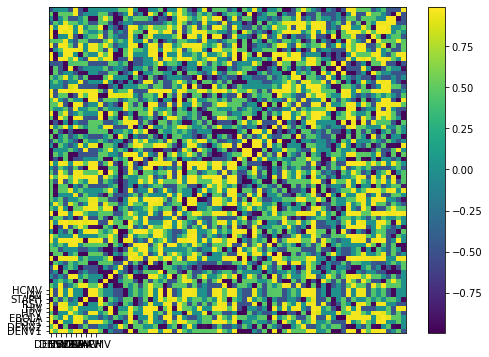

In [49]:
#han_mtx = association_mtx(rank_dict_small,print_time=True,draw=True)

In [51]:
np.save('pickles/han_mtx.npy', han_mtx) 

In [17]:
han_mtx = np.load('pickles/han_mtx.npy',allow_pickle=True)

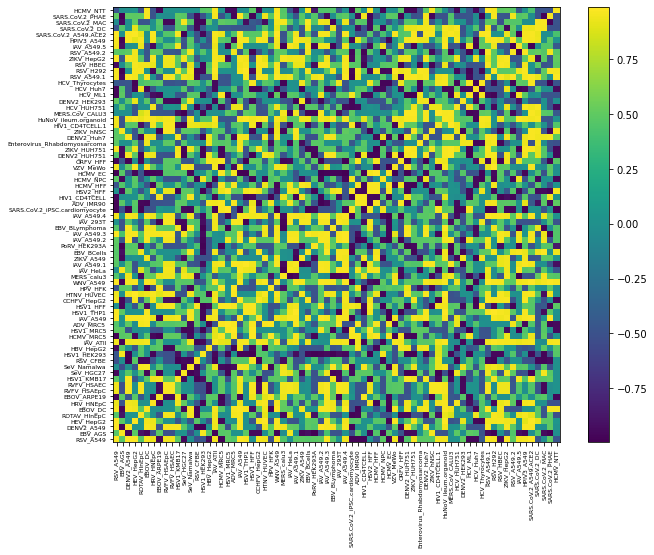

In [18]:
heatmap(han_mtx)

<a id='5'></a>
### 5. HVR network

In [19]:
#param G: networkx Graph; original graph from which to remove edges
#param thresh: float; upper limit for weight
#remove all edges with weights < thresh, return new graph
def impose_cutoff(G,thresh):
    for (n1,n2) in G.edges():
        if abs(G[n1][n2]['weight']) < thresh:
            G.remove_edge(n1,n2)
    return G

In [80]:
G = nx.from_numpy_matrix(han_mtx)
draw_graph(G,'G')

G


In [81]:
G_75 = impose_cutoff(G,0.75)
draw_graph(G_75,'G_75')

G_75


In [82]:
G_90 = impose_cutoff(G,0.9)
draw_graph(G_90,'G_90')

G_90


In [83]:
G_95 = impose_cutoff(G,0.95)
draw_graph(G_95,'G_95')

G_95


<a id='6'></a>
### 6. Community detection

In [73]:
def louvain(G):
    G_tmp = G.copy()
    for node in G_tmp:
        G_tmp.nodes[node]['weight'] = 1
    partition = community_louvain.best_partition(G_tmp)
    for node in partition.keys():
        G.nodes[node]['louvain_group'] = partition[node]
    return G

In [74]:
G_louvain_95 = louvain(G_95)

In [79]:
draw_graph(G_louvain_95,'0.95 threshold, louvain partition',attr='louvain_group',show=True)

0.95 threshold, louvain partition


In [66]:
G_louvain.nodes[1]

{'louvain_group': 1, 'weight': 1}

In [30]:
partition.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71])

In [31]:
for node in partition.keys():
    G.nodes[node]['louvain_group'] = partition[node]

In [40]:
G.nodes[1]

{}

In [29]:
type(partition)

dict

In [52]:
def Q(G,label):
    
    def delta(i,j):
        if G.nodes[i][label] == G.nodes[j][label]: return True
        return False
    
    m = len(G.edges())
    summ = 0
    for i in G.nodes():
        for j in G.nodes():
            summ += G.edges[i][j]['weight'] - (G.degree(i)*G.degree(j)/(2*m)) * delta(i,j)
    
    return summ/(2*m)

In [ ]:
def greedy_agglomeration():
    